In [25]:
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import rfft, fft, ifft, fftfreq, rfftfreq
from scipy.optimize import curve_fit
from scipy.stats import norm
plt.close('all')

fontsize = 14
mpl.rcParams.update(
    {
        "text.usetex": False,
        "figure.figsize": (9, 6),
        "figure.autolayout": False,
        # "font.family": "serif",
        # "font.serif": "DejaVu Serif",
        # 'mathtext.fontset': 'cm',
        "lines.linewidth": 1.5,
        "font.size": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fancybox": True,
        "legend.fontsize": fontsize,
        "legend.framealpha": 0.7,
        "legend.handletextpad": 0.5,
        "legend.labelspacing": 0.2,
        "legend.loc": "best",
        "axes.edgecolor": "#b0b0b0",
        "grid.color": "#707070",  # grid color"
        "xtick.color": "#b0b0b0",
        "ytick.color": "#b0b0b0",
        "savefig.dpi": 80,
        "pdf.compression": 9,
    }
)

In [27]:
### Import helper functions from https://github.com/cwfink1/phys657-spring2026/blob/main/Module3/problem_3_helper.ipynb
def foldpsd(psd, fs):
    """
    Return the one-sided version of the inputted two-sided psd. Supports an n-dimensional array outputted by `calc_psd`.
    
    Parameters
    ----------
    psd : ndarray
        A two-sided psd to be converted to one-sided
    fs : float
        The sample rate used for the psd

    Returns
    -------
    f : ndarray
        The frequencies corresponding to the outputted one-sided psd
    psd_folded : ndarray
        The one-sided (folded over) psd corresponding to the inputted two-sided psd

    """

    psd_len = psd.shape[-1]
    psd_folded = np.copy(psd[...,:psd_len//2 + 1])
    psd_folded[..., 1:psd_len//2 + (psd_len)%2] *= 2.0
    f = rfftfreq(psd_len, d=1.0/fs)
    
    return f, psd_folded


def calc_psd(x, fs=1.0, folded_over=True):
    """Return the PSD of an n-dimensional array, assuming that we want the PSD of the last axis.
    
    Parameters
    ----------
    x : array_like
        Array to calculate PSD of.
    fs : float, optional
        Sample rate of the data being taken, assumed to be in units of Hz.
    folded_over : bool, optional
        Boolean value specifying whether or not the PSD should be folded over. 
        If True, then the symmetric values of the PSD are multiplied by two, and
        we keep only the positive frequencies. If False, then the entire PSD is 
        saved, including positive and negative frequencies. Default is to fold
        over the PSD.
            
    Returns
    -------
    f : ndarray
        Array of sample frequencies
    psd : ndarray
        Power spectral density of 'x'
        
    """
    
    # calculate normalization for correct units
    norm = fs * x.shape[-1]
    
    if folded_over:
        # if folded_over = True, we calculate the Fourier Transform for only the positive frequencies
        if len(x.shape)==1:
            psd = (np.abs(rfft(x))**2.0)/norm
        else:
            psd = np.mean(np.abs(rfft(x))**2.0, axis=0)/norm
            
        # multiply the necessary frequencies by two (zeroth frequency should be the same, as
        # should the last frequency when x.shape[-1] is odd)
        psd[1:x.shape[-1]//2+1 - (x.shape[-1]+1)%2] *= 2.0
        f = rfftfreq(x.shape[-1], d=1.0/fs)
    else:
        # if folded_over = False, we calculate the Fourier Transform for all frequencies
        if len(x.shape)==1:
            psd = (np.abs(fft(x))**2.0)/norm
        else:
            psd = np.mean(np.abs(fft(x))**2.0, axis=0)/norm
            
        f = fftfreq(x.shape[-1], d=1.0/fs)
    return f, psd

def optimal_filter_amp(signal, template, psd, fs, coupling="AC"):
    """
    Compute the no-delay optimal filter amplitude for a single trace.

    Conventions / assumptions
    -------------------------
    - 'psd' is the full two-sided PSD (length = nbins).
    - FFT normalization follows the convention used in the OptimalFilter class:
        S = fft(template) / nbins / df
        V = fft(signal)   / nbins / df
      where df = fs / nbins.
    - If coupling == "AC" then the zero-frequency bin is ignored (psd[0] set to inf).
    - No time-shifts, no integralnorm, no chi2 / interpolation — just amplitude + sigma.

    Parameters
    ----------
    signal : 1D ndarray
        Time-domain trace (length nbins).
    template : 1D ndarray
        Template pulse (length nbins). Should be aligned/sampled to same grid.
    psd : 1D ndarray
        Two-sided PSD (length nbins). Can contain np.inf at index 0 for AC coupling.
    fs : float
        Sampling rate in Hz.
    coupling : {"AC","DC"}, optional
        If "AC" (default) will set psd[0] = np.inf to ignore DC.

    Returns
    -------
    amp : float
        Optimal filter amplitude (real scalar).
    sigma : float
        Expected 1-sigma amplitude resolution: 1/sqrt(norm).
    """
    signal = np.asarray(signal)
    template = np.asarray(template)
    psd = np.asarray(psd)

    if signal.ndim != 1 or template.ndim != 1 or psd.ndim != 1:
        raise ValueError("signal, template, and psd must be 1D arrays")

    nbins = signal.size
    if not (template.size == nbins == psd.size):
        raise ValueError("signal, template, and psd must have the same length")

    # frequency spacing
    df = fs / nbins

    # make a safe copy of PSD and apply coupling choice
    psd_safe = psd.astype(float).copy()
    if coupling == "AC":
        psd_safe[0] = np.inf

    # avoid division by zero on other bins (tiny floor)
    tiny = np.finfo(float).tiny
    psd_safe = np.where(np.isfinite(psd_safe), np.maximum(psd_safe, tiny), psd_safe)

    # FFT normalization matching the class conventions
    S = fft(template) / nbins / df   # complex
    V = fft(signal)   / nbins / df   # complex

    # frequency-domain filter (phi) and normalization (norm)
    phi = np.conjugate(S) / psd_safe
    norm = np.real(np.dot(phi, S)) * df   # scalar, should be >0 for nonzero template

    if norm <= 0:
        raise RuntimeError("Computed norm is non-positive (check template/psd)")

    # matched numerator
    num = np.sum(phi * V) * df         # complex in general
    amp = np.real(num) / norm          # final amplitude (real)

    # expected 1-sigma energy resolution
    sigma = 1.0 / np.sqrt(norm)

    return amp, sigma

def _pick_top_hist_peaks(counts, centers, n):
    """Pick up to n well-separated peak centers from histogram counts."""
    sm = np.convolve(counts, np.ones(3)/3, mode='same')
    order = np.argsort(sm)[::-1]
    chosen = []
    min_sep = (centers[1] - centers[0]) * 6.0
    for idx in order:
        c = centers[idx]
        if all(abs(c - cc) > min_sep for cc in chosen):
            chosen.append(c)
        if len(chosen) >= n:
            break
    if len(chosen) < n:
        # fallback: even spacing
        qs = np.linspace(0.1, 0.9, n)
        chosen = list(np.quantile(centers, qs))
    return np.array(sorted(chosen))


def fit_spectrum_curvefit(amplitudes,
                          n_lines=3,
                          mus_guess=None,
                          sig_guess=None,
                          include_flat=True,
                          bins=120,
                          range_vals=None,
                          verbose=False):
    """
    Fit binned counts with n_lines Gaussians + optional flat background using scipy.curve_fit.

    Parameters
    ----------
    amplitudes : 1D array
        Amplitude measurements (one number per event).
    n_lines : int
        Number of Gaussian spectral lines to fit.
    mus_guess : sequence or None
        Optional initial guesses for Gaussian centers (length n_lines). If None, inferred from histogram peaks.
    sig_guess : sequence or None
        Optional initial guesses for standard deviations (length n_lines). If None, default small values based on data span.
    include_flat : bool
        If True, include a flat counts-per-bin background term.
    bins, range_vals : histogram binning passed to np.histogram
    verbose : bool
        Print fitted parameter summary.

    Returns
    -------
    result : dict with keys
        'bin_centers','bin_edges','counts','areas','mus','sigs','weights',
        'flat_counts_per_bin','flat_fraction_est','model_counts','popt','pcov'
    """
    x = np.asarray(amplitudes).ravel()
    N = x.size

    counts, edges = np.histogram(x, bins=bins, range=range_vals)
    centers = 0.5 * (edges[:-1] + edges[1:])
    bw = edges[1] - edges[0]
    span = edges[-1] - edges[0]

    n_gauss = int(n_lines)
    # default guesses
    if mus_guess is None:
        mus_guess = _pick_top_hist_peaks(counts, centers, n_gauss)
    else:
        mus_guess = np.asarray(mus_guess).ravel()
        if mus_guess.size != n_gauss:
            raise ValueError("mus_guess must have length == n_lines")

    if sig_guess is None:
        # narrow for lines: few percent of span
        sig_guess = np.full(n_gauss, max(1e-3, 0.03 * span))
    else:
        sig_guess = np.asarray(sig_guess).ravel()
        if sig_guess.size != n_gauss:
            raise ValueError("sig_guess must have length == n_lines")

    # Model: counts per bin = sum_j area_j * pdf(center | mu_j, sigma_j) * bin_width + flatC
    def _model_counts(x_centers, *p):
        out = np.zeros_like(x_centers, dtype=float)
        ptr = 0
        for g in range(n_gauss):
            area = p[ptr]; mu = p[ptr+1]; sig = p[ptr+2]
            ptr += 3
            out += area * norm.pdf(x_centers, loc=mu, scale=max(1e-9, abs(sig))) * bw
        if include_flat:
            flatC = p[ptr]
            out = out + max(0.0, flatC)
        return out

    # initial parameter vector p0: [area1, mu1, sig1, area2, mu2, sig2, ..., flatC?]
    total_guess_area = N
    base_area = total_guess_area / (n_gauss + (1 if include_flat else 0))
    p0 = []
    for i in range(n_gauss):
        # approximate peak height -> area guess (robust)
        idx_closest = np.argmin(np.abs(centers - mus_guess[i]))
        peak_h = counts[idx_closest]
        est_area = peak_h * (sig_guess[i] * np.sqrt(2*np.pi))
        est_area = max(est_area, base_area * 0.1)
        p0.extend([float(est_area), float(mus_guess[i]), float(sig_guess[i])])

    if include_flat:
        flat_guess = max(0.0, np.median(counts) * 0.2)
        p0.append(float(flat_guess))

    p0 = np.asarray(p0, dtype=float)

    # bounds
    lower = []
    upper = []
    for g in range(n_gauss):
        lower.extend([0.0, edges[0] - 0.2*span, 1e-6])        # area >=0, mu within extended range, sig > 0
        upper.extend([N*10.0, edges[-1] + 0.2*span, span*1.0])
    if include_flat:
        lower.append(0.0)
        upper.append(float(N*0.5))

    try:
        popt, pcov = curve_fit(_model_counts, centers, counts, p0=p0, bounds=(lower, upper), maxfev=50000)
    except Exception as exc:
        if verbose:
            print("curve_fit exception (retrying without bounds):", exc)
        popt, pcov = curve_fit(_model_counts, centers, counts, p0=p0, maxfev=50000)

    # unpack
    ptr = 0
    areas = []
    mus = []
    sigs = []
    for g in range(n_gauss):
        a = float(popt[ptr]); mu = float(popt[ptr+1]); s = abs(float(popt[ptr+2]))
        ptr += 3
        areas.append(a); mus.append(mu); sigs.append(s)

    flatC = float(popt[ptr]) if include_flat else 0.0

    # approximate fractions (area-weighted)
    denom = np.sum(areas) + (flatC * span / bw if include_flat else 0.0)
    if denom <= 0:
        weights = np.array([a / max(1e-12, np.sum(areas)) for a in areas])
        flat_frac = 0.0
    else:
        weights = np.array(areas) / denom
        flat_frac = (flatC * span / bw) / denom if include_flat else 0.0

    model_counts = _model_counts(centers, *popt)

    result = {
        "bin_centers": centers,
        "bin_edges": edges,
        "counts": counts,
        "areas": np.array(areas),
        "mus": np.array(mus),
        "sigs": np.array(sigs),
        "weights": weights,
        "flat_counts_per_bin": float(flatC),
        "flat_fraction_est": float(flat_frac),
        "model_counts": model_counts,
        "popt": popt,
        "pcov": pcov
    }

    if verbose:
        print("mus:", result["mus"])
        print("sigs:", result["sigs"])
        print("areas:", result["areas"])
        print("flat per bin:", result["flat_counts_per_bin"])
        print("flat fraction (est):", result["flat_fraction_est"])

    return result


## Problem 3: Matched Filtering, Calibration, and Detection Efficiency 

In this assigment you will analyze simulated dector data contianing non-white noise, the monoenergetic nuclear decay lines, and a flat background. Your goal is to extract optimal energy estimate, calibrate the detecor response, and measure detection effciency. 

You will be provided with the waveforms datasets which will be measurmetsn of volatea vs time. The datasets given consists of noise data, and events consitign of triggered pulses. The pulses are embedded in collored (non-white) nosie and include:
* Three spectal lines from nuclear decays
* A broad "noise blob" population
* A flat background of random triggers

Your task if to  determine the detector performacnce using three different estimators: 
1. Matched/Optimal Filter amplitude estimator (MF)
2. Naive peak estimator (maximum sample or fixed index estimator)
3. Intefral estimator (sum/integral over pulse window)

You must compare their energy resolutoin and detection efficiency

## Part I: Matched filter amplitudes
1. Construct a noise power spectral density $(PSD), J(f)$, estimate using the noise-only dataset. Plot the (one-side) PSD on a log-log plot
2. Build a matched filter using a template pulse $s(t)$ and the measured PSD: 
$$
a_{\text{MF}} = \frac{\sum_{k}\tilde{s^{*}}d(f_k)/J(f_k)}{\sum_k |\tilde{s}(f_k)|^2 /J(f_k)}
$$
where $\tilde{d}(f_k)$ and $\tilde{s}(f_k)$ are the fourier transform of the data and template respectively. Our pulse template is nrmalized to have a maximum amplitude of one, and scales as 

$$
s(t) \propto e^{(-t/\tau_{\text{fall}})} - e^{(-t/\tau_{\text{rise}})}
$$

where $\tau_{\text{rise}} = 100 \mu s$ and $\tau_{\text{fall}} = 5 \mu s$

3. Apply the matched filter to all events and extract and amplitude for each pulse. 

4. Plot a histogram of the mreasured amplitudes. 


In [28]:
# PROBLEM 3
plt.style.use('dark_background')

noise = np.load("NoiseTraces.npy")
events = np.load("EventTraces.npy")

# constants from problem_3_helper.ipynb
fs = 5000  # Hz
dt = 1/fs
N = 4096   # bins per trace

t = np.arange(N) * dt
freqs = np.fft.rfftfreq(N, dt)

### **Step 1: One-Sided Noise PSD**

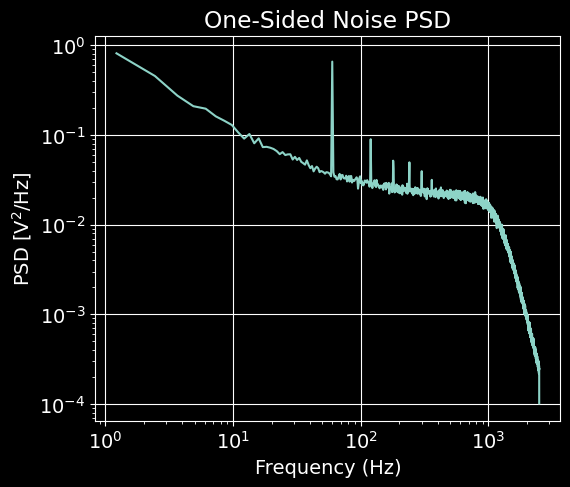

In [32]:
# compute PSD
f_psd, psd = calc_psd(noise, fs=fs, folded_over=True)

plt.figure(figsize=(6,5))
plt.loglog(f_psd[1:], psd[1:])
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD [V$^2$/Hz]")
plt.title("One-Sided Noise PSD")
plt.grid(True)
plt.show()

### **Step 2: Matched Filter Template**
Given:
$$
s(t)\propto e^{-t/T_{fall}}-e^{-t/\tau_{rise}}
$$

with $\tau_{rise}=100\:\mu s$ and $\tau_{fall}=5\:\mu s$

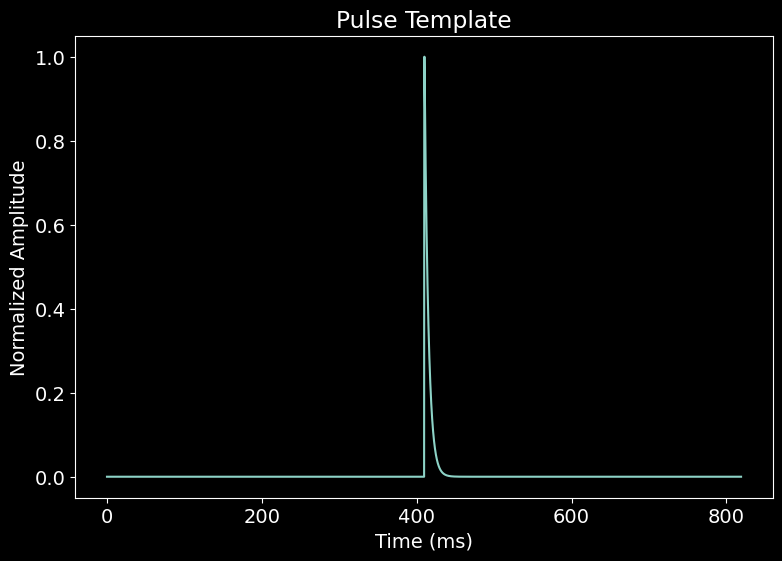

In [34]:
N = events.shape[1]
dt = 1/fs
t = np.arange(N) * dt

tau_rise = 100e-6
tau_fall = 5e-3

# center pulse in trace
t0 = (N//2) * dt
t_shift = t - t0

template = np.zeros_like(t)
mask = t_shift >= 0
template[mask] = np.exp(-t_shift[mask]/tau_fall) - np.exp(-t_shift[mask]/tau_rise)

# normalize to peak = 1
template /= np.max(template)

plt.plot(t*1000, template)
plt.xlabel("Time (ms)")
plt.ylabel("Normalized Amplitude")
plt.title("Pulse Template")
plt.show()

### **Step 3: Construct the Matched Filter and Apply**

In [38]:
f_full, psd_full = calc_psd(noise, fs=fs, folded_over=False)

mf_amps = []
mf_sigmas = []

for trace in events:
    amp, sigma = optimal_filter_amp(trace, template, psd_full, fs, coupling="AC")
    mf_amps.append(amp)
    mf_sigmas.append(sigma)

mf_amps = np.array(mf_amps)
mf_sigmas = np.array(mf_sigmas)

print("Mean expected sigma (resolution):", np.mean(mf_sigmas))

Mean expected sigma (resolution): 2.4985434674052205


### **Step 5: Histogram of Matched Filter Amplitudes**

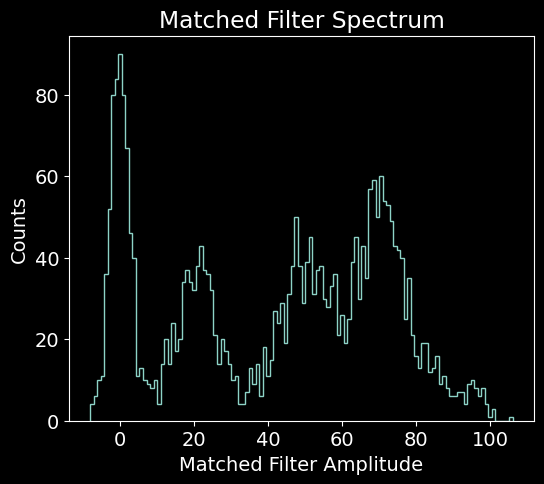

In [42]:
plt.figure(figsize=(6,5))
plt.hist(mf_amps, bins=120, histtype='step')
plt.xlabel("Matched Filter Amplitude")
plt.ylabel("Counts")
plt.title("Matched Filter Spectrum")
plt.show()

## Part II: Spectral Model and Peak Extraction (Using Provided Fit Function)

In counting experiments, a histogram bin does not measure a continuous probability density. It measures an integer number of events. Therefore, the statistically correct likelihood is a Poisson likelihood.

If $n_j$ is the observed number of events in bin $j$ and $\lambda_j(\theta)$ is the model prediction, then

$$
L(\theta) = \prod_j \frac{\lambda_j^{n_j} e^{-\lambda_j}}{n_j!}.
$$

Maximizing this likelihood gives the optimal parameter estimates and is the standard method used in particle physics and astronomy analyses.

However, implementing this optimizer requires careful numerical treatment of many correlated parameters and is beyond the scope of this assignment.

Instead, we will use a simpler least-squares fit to the histogram. For well-populated bins, the Poisson distribution approaches a Gaussian, so minimizing squared residuals gives nearly identical results in practice.

You will be given a fitting routine, `fit_spectrum_curvefit()`, which performs a least-squares fit of the histogrammed amplitude spectrum to the model

$$
N(A) =
\sum_{i=1}^{N_{\text{lines}}}
N_i \, \mathcal{N}(A \mid \mu_i, \sigma_i^2)
+ C_{\text{flat}},
$$

where:

- $N_i$ is the total number of events in spectral line $i$  
- $\mu_i$ is the measured line amplitude  
- $\sigma_i$ is the detector resolution  
- $C_{\text{flat}}$ is a uniform background rate per bin  

The fit function returns the best-fit parameters and the model prediction.

---

### Tasks

1. Construct a histogram of the reconstructed amplitudes and call `fit_spectrum` to obtain the fit.

2. Plot the histogram (counts) and overlay the fitted $\lambda_j$ (expected counts per bin) from the fit, as well as the individual Gaussian components and the flat background contribution.

3. Identify the three signal peaks and record their fitted amplitudes $A_1$, $A_2$, $A_3$, as well as for the “noise blob.” Use $\sigma_i$ from the fitter as the resolution for each peak.  
   (If you wish to propagate parameter covariances to uncertainties, you may, but this is optional.)

4. Include one diagnostic plot of the negative log-likelihood evaluated versus $\mu_1$ (scan a small window around the fitted value) to demonstrate the likelihood peak and uncertainty behavior.

In [70]:
# define pulse window (centered)
center = N // 2       # middle of trace
window = 512          # number of bins to sum on either side
start = max(center - window, 0)
end = min(center + window, N)

# compute integral amplitudes
int_amps = events[:, start:end].sum(axis=1)

### **Task 1:** Histogram + Fit Using `fit_spectrum_curvefit`

In [76]:
from scipy.stats import norm

# params
N = event_traces.shape[1]       # number of bins per trace
center = N // 2                 # pulse centered in trace
window = 512                     # number of bins to sum over for integral
start = center - window
end = center + window

# compute baseline from first 200 bins
baseline = event_traces[:, :200].mean(axis=1, keepdims=True)

# integral amplitudes (sum over pulse window minus baseline)
int_amps = (event_traces[:, start:end] - baseline).sum(axis=1)

# use fit_spectrum_curvefit
res_int = fit_spectrum_curvefit(
    int_amps,
    n_lines=4,          # 3 signal peaks + 1 noise blob
    include_flat=True,
    bins=120,
    verbose=True
)

curve_fit exception (retrying without bounds): Initial guess is outside of provided bounds
mus: [-749.09367522  -94.00167879 2605.48331757 3357.50431224]
sigs: [1793.55273264  368.74519255 1669.68706819  930.28872752]
areas: [1186.46443838   53.87059783 1919.69780967 -293.89425919]
flat per bin: 1.1174035140767475
flat fraction (est): 0.04469275868612991


### **Task 2:** Plot Histogram, Model, and Components

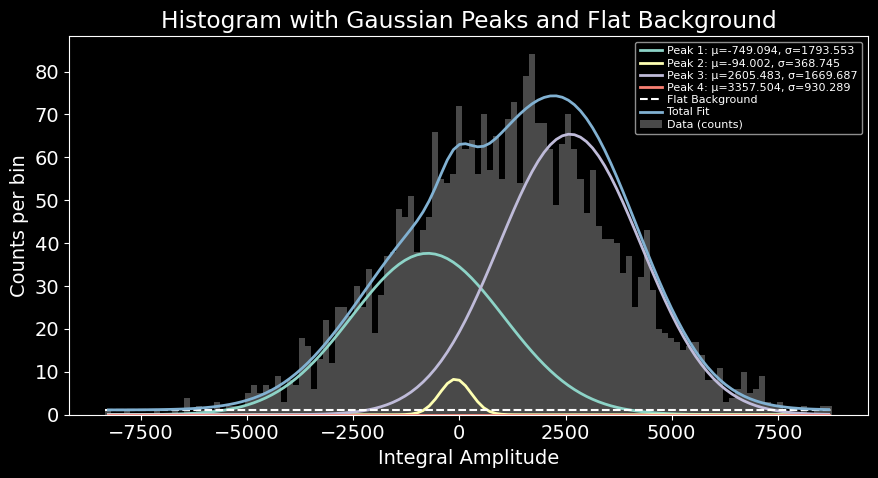

In [77]:
from scipy.stats import norm

bin_centers = res_int['bin_centers']
bin_edges = res_int['bin_edges']
counts = res_int['counts']
areas_clipped = np.maximum(res_int['areas'], 0.0)  # clip negative areas
mus = res_int['mus']
sigs = res_int['sigs']
flatC = res_int['flat_counts_per_bin']
bin_width = bin_edges[1] - bin_edges[0]

plt.figure(figsize=(9,5))

# histogram of counts
plt.bar(bin_centers, counts, width=bin_width, alpha=0.35, color='lightgray', label='Data (counts)')

# individual gaussian components
for i, area in enumerate(areas_clipped):
    gaussian = area * norm.pdf(bin_centers, loc=mus[i], scale=sigs[i]) * bin_width
    plt.plot(bin_centers, gaussian, lw=2, label=f'Peak {i+1}: μ={mus[i]:.3f}, σ={sigs[i]:.3f}')

# Flat background
plt.hlines(flatC, xmin=bin_edges[0], xmax=bin_edges[-1], linestyles='dashed', label='Flat Background')

# Total model (sum of Gaussians + flat background)
total_model = np.zeros_like(bin_centers)
for i, area in enumerate(areas_clipped):
    total_model += area * norm.pdf(bin_centers, loc=mus[i], scale=sigs[i]) * bin_width
total_model += flatC
plt.plot(bin_centers, total_model, '-', lw=2, label='Total Fit')

plt.xlabel('Integral Amplitude')
plt.ylabel('Counts per bin')
plt.title('Histogram with Gaussian Peaks and Flat Background')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

### **Task 3:** Fitted Peak Amplitudes

In [78]:
# clipping negative areas to zero bc i'm confused
areas_clipped = np.maximum(res_int['areas'], 0.0)
mus = res_int['mus']
sigs = res_int['sigs']

# identify peaks
A1, A2, A3 = areas_clipped[:3]
sigma1, sigma2, sigma3 = sigs[:3]

# noise blob
A_blob = areas_clipped[3]
sigma_blob = sigs[3]

# print results
print("=== Signal Peaks ===")
print(f"A1 = {A1:.3f}, σ1 = {sigma1:.3f}")
print(f"A2 = {A2:.3f}, σ2 = {sigma2:.3f}")
print(f"A3 = {A3:.3f}, σ3 = {sigma3:.3f}")
print("\n=== Noise Blob ===")
print(f"A_blob = {A_blob:.3f}, σ_blob = {sigma_blob:.3f}")

=== Signal Peaks ===
A1 = 1186.464, σ1 = 1793.553
A2 = 53.871, σ2 = 368.745
A3 = 1919.698, σ3 = 1669.687

=== Noise Blob ===
A_blob = 0.000, σ_blob = 930.289


### **Task 4:** Diagnostic Plot  
We performed a likelihood scan by varying the mean $\mu_1$ of the first signal peak while keeping all other fit parameters fixed. For each value of $\mu_1$, we computed the negative log-likelihood of the histogram data under the Poisson model. This curve demonstrates the peak location and the uncertainty associated with  $\mu_1$.

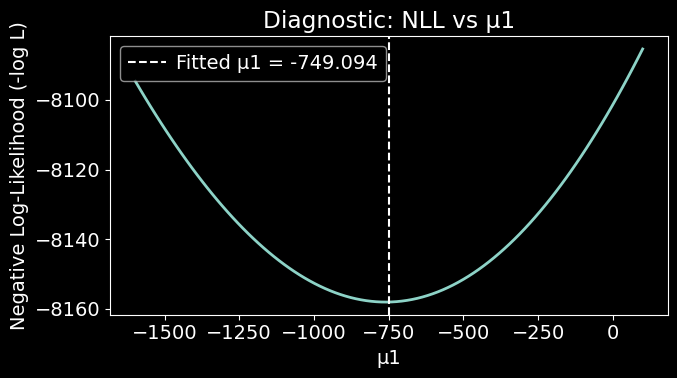

In [80]:
# extract fitted parameters
counts = res_int['counts']
bin_centers = res_int['bin_centers']
bin_width = bin_centers[1] - bin_centers[0]
mus = res_int['mus'].copy()
sigs = res_int['sigs']
areas = res_int['areas']
flatC = res_int['flat_counts_per_bin']

# range to scan around mu1
mu1_fit = mus[0]
scan_width = 0.05 * (bin_centers[-1] - bin_centers[0])  # 5% of total span
mu1_values = np.linspace(mu1_fit - scan_width, mu1_fit + scan_width, 100)

# function to compute negative log-likelihood for a fixed mu1
def neg_log_likelihood(mu1_val):
    mus_temp = mus.copy()
    mus_temp[0] = mu1_val  # vary only mu1
    
    # compute expected counts in each bin (λ_j)
    lambda_j = np.zeros_like(bin_centers)
    for i in range(len(areas)):
        lambda_j += areas[i] * norm.pdf(bin_centers, loc=mus_temp[i], scale=sigs[i]) * bin_width
    lambda_j += flatC  # add flat background
    
    # poisson log-likelihood
    # avoid log(0) by clipping lambda_j...
    lambda_j = np.clip(lambda_j, 1e-12, None)
    ll = np.sum(counts * np.log(lambda_j) - lambda_j)
    
    return -ll  # negative log-likelihood

# evaluate NLL over the scan range
nll_values = np.array([neg_log_likelihood(mu) for mu in mu1_values])

# plot
plt.figure(figsize=(7,4))
plt.plot(mu1_values, nll_values, '-', lw=2)
plt.axvline(mu1_fit, linestyle='--', label=f'Fitted μ1 = {mu1_fit:.3f}')
plt.xlabel("μ1")
plt.ylabel("Negative Log-Likelihood (-log L)")
plt.title("Diagnostic: NLL vs μ1")
plt.legend()
plt.tight_layout()
plt.show()

## Part III: Energy Calibration

You will be provided with the true energies of the three lines:

$$
E_{\text{true},1} = 25~\text{keV}, \quad
E_{\text{true},2} = 65~\text{keV}, \quad
E_{\text{true},3} = 100~\text{keV}.
$$

The detector response follows the nonlinear saturation model:

$$
E_{\text{recon}} = a \left[ 1 - \exp\left( -\frac{E_{\text{true}}}{b} \right) \right].
$$

---

### Tasks

1. Fit for calibration parameters $a$ and $b$.  

2. Construct the inverse calibration function to convert measured amplitudes to reconstructed energy $E_{\text{rec}}$.  

3. Convert the full amplitude spectrum into an energy spectrum.  

4. Comment on the benefits of the above saturation model versus a polynomial or spline fit.

Fitted calibration parameters: a = 8509922.438, b = 561283.485


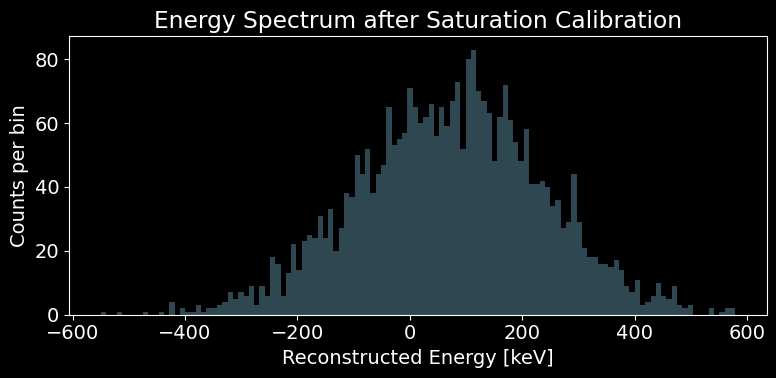

In [83]:
# measured amplitudes from part II
amp_meas = np.array([A1, A2, A3])

# true energies
E_true = np.array([25, 65, 100])

# saturation model
def saturation_model(E, a, b):
    return a * (1 - np.exp(-E / b))

# fit for a and b
popt, pcov = curve_fit(saturation_model, E_true, amp_meas, p0=[max(amp_meas), 50])
a_fit, b_fit = popt
print(f"Fitted calibration parameters: a = {a_fit:.3f}, b = {b_fit:.3f}")

# inverse calibration: convert amplitude back to reconstructed energy
def inverse_saturation(A, a, b):
    """Invert the saturation model to get E_recon from measured amplitude"""
    return -b * np.log(1 - A / a)

# convert full amplitude spectrum to energy spectrum
int_amps_energy = inverse_saturation(int_amps, a_fit, b_fit)

# plot reconstructed energy spectrum
plt.figure(figsize=(8,4))
plt.hist(int_amps_energy, bins=120, alpha=0.35, color='skyblue')
plt.xlabel("Reconstructed Energy [keV]")
plt.ylabel("Counts per bin")
plt.title("Energy Spectrum after Saturation Calibration")
plt.tight_layout()
plt.show()

A saturation model captures the physical behavior of the detector, particularly the flattening of response at high energies. A polynomial or spline might overfit or oscillate between calibration points.

## Part IV: Detection Threshold

Define a detection threshold using the noise population:

$$
E_{\text{thresh}} = \mu_n + 5 \sigma_n.
$$

---

### Tasks

1. Determine the corresponding energy threshold after calibration.  

2. Plot the calibrated spectrum and mark the threshold.

Detection threshold: Amplitude = 8008.948, Energy = 528.490 keV


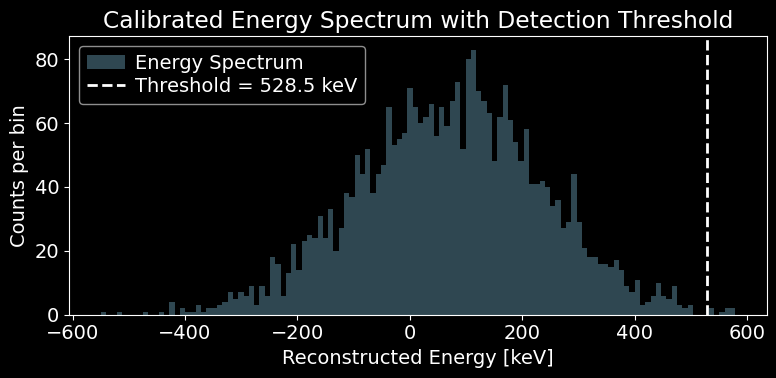

In [87]:
# noise blob parameters from Part II
mu_noise = mus[3]    # mean amplitude of noise blob
sigma_noise = sigs[3]  # resolution of noise blob

# energy threshold using 5-sigma above noise
A_thresh = mu_noise + 5 * sigma_noise
E_thresh = inverse_saturation(A_thresh, a_fit, b_fit)
print(f"Detection threshold: Amplitude = {A_thresh:.3f}, Energy = {E_thresh:.3f} keV")

# convert full amplitude spectrum to energy
int_amps_energy = inverse_saturation(int_amps, a_fit, b_fit)

# plot calibrated energy spectrum with threshold
plt.figure(figsize=(8,4))
plt.hist(int_amps_energy, bins=120, alpha=0.35, color='skyblue', label='Energy Spectrum')
plt.axvline(E_thresh, linestyle='--', lw=2, label=f'Threshold = {E_thresh:.1f} keV')
plt.xlabel('Reconstructed Energy [keV]')
plt.ylabel('Counts per bin')
plt.title('Calibrated Energy Spectrum with Detection Threshold')
plt.legend()
plt.tight_layout()
plt.show()

## Part V: Detection Efficiency

You will now simulate pulses of known amplitude.

---

### Tasks

1. Inject fake pulses of known true energy into real noise.  

2. Process them through the full analysis chain.  

3. A pulse is “detected” if $E_{\text{rec}} > E_{\text{thresh}}$.  

Measure the efficiency:

$$
\varepsilon(E) = \frac{N_{\text{detected}}(E)}{N_{\text{injected}}(E)}.
$$

Plot efficiency versus energy.